# Amazon Product Reviews Sentiment Analysis

<img src='https://webcdn.getmidas.com/uploads/2023/04/Amazon-armazem-1-1024x576.jpeg'>

Bu çalışmanın amacı, Amazon ürün incelemeleri veri seti kullanılarak doğal dil işleme (NLP) teknikleri ile metin verilerinden duygu (sentiment) çıkarımı gerçekleştirmektir. Kullanıcılar tarafından yazılan yorumların olumlu, nötr veya olumsuz olarak sınıflandırılması hedeflenmiştir.

The aim of this study is to extract sentiment from text data using natural language processing (NLP) techniques with the Amazon product review dataset. The goal is to classify user-written reviews as positive, neutral, or negative.


In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

from textblob import TextBlob
import matplotlib.pyplot as plt
import seaborn as sns

import warnings 
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split

from collections import Counter
import neattext.functions as nfx
from nltk.corpus import stopwords

C:\Users\LENOVO\anaconda3\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


In [2]:
df = pd.read_csv("amazon_reviews.csv")

### EDA

In [7]:
df.head()

,Unnamed: 0,reviewerName,overall,reviewText,reviewTime,day_diff,helpful_yes,helpful_no,total_vote,score_pos_neg_diff,score_average_rating,wilson_lower_bound
0,0,NaN,4.0,No issues.,2014-07-23,138,0,0,0,0,0.0,0.0
1,1,0mie,5.0,"Purchased this for my device, it worked as adv...",2013-10-25,409,0,0,0,0,0.0,0.0
2,2,1K3,4.0,it works as expected. I should have sprung for...,2012-12-23,715,0,0,0,0,0.0,0.0
3,3,1m2,5.0,This think has worked out great.Had a diff. br...,2013-11-21,382,0,0,0,0,0.0,0.0
4,4,2&amp;1/2Men,5.0,"Bought it with Retail Packaging, arrived legit...",2013-07-13,513,0,0,0,0,0.0,0.0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4915 entries, 0 to 4914
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Unnamed: 0            4915 non-null   int64  
 1   reviewerName          4914 non-null   object 
 2   overall               4915 non-null   float64
 3   reviewText            4914 non-null   object 
 4   reviewTime            4915 non-null   object 
 5   day_diff              4915 non-null   int64  
 6   helpful_yes           4915 non-null   int64  
 7   helpful_no            4915 non-null   int64  
 8   total_vote            4915 non-null   int64  
 9   score_pos_neg_diff    4915 non-null   int64  
 10  score_average_rating  4915 non-null   float64
 11  wilson_lower_bound    4915 non-null   float64
dtypes: float64(3), int64(6), object(3)
memory usage: 460.9+ KB


In [5]:
df.isnull().sum()

Unnamed: 0              0
reviewerName            1
overall                 0
reviewText              1
reviewTime              0
day_diff                0
helpful_yes             0
helpful_no              0
total_vote              0
score_pos_neg_diff      0
score_average_rating    0
wilson_lower_bound      0
dtype: int64

In [8]:
df= df.dropna(how="any") 

In [9]:
df.isnull().sum()

Unnamed: 0              0
reviewerName            0
overall                 0
reviewText              0
reviewTime              0
day_diff                0
helpful_yes             0
helpful_no              0
total_vote              0
score_pos_neg_diff      0
score_average_rating    0
wilson_lower_bound      0
dtype: int64

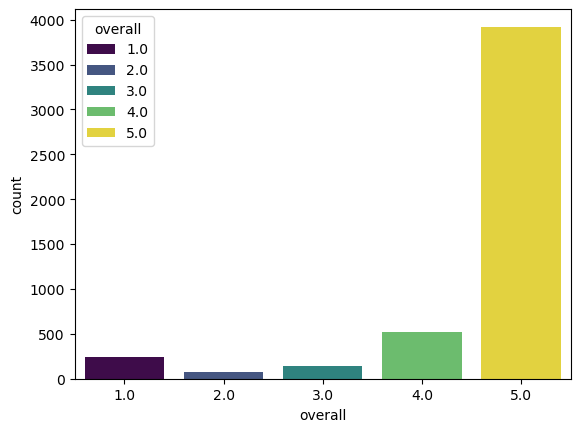

In [10]:
sns.countplot(x=df['overall'], hue=df['overall'], palette='viridis');

In [11]:
from langdetect import detect
df["language"] = df["reviewText"].apply(detect)

In [12]:
df["language"].value_counts()

language
en    4887
es       5
ca       4
af       4
it       2
fr       2
cy       1
cs       1
ro       1
sl       1
hr       1
so       1
pt       1
de       1
id       1
Name: count, dtype: int64

In [13]:
df = df[df["language"] == 'en']

In [14]:
df=df.reset_index(drop=True)

In [16]:
df = df[["overall", "reviewText"]]

In [17]:
df.head()

,overall,reviewText
0,5.0,"Purchased this for my device, it worked as adv..."
1,4.0,it works as expected. I should have sprung for...
2,5.0,This think has worked out great.Had a diff. br...
3,5.0,"Bought it with Retail Packaging, arrived legit..."
4,5.0,It's mini storage. It doesn't do anything els...


In [20]:
def label_sentiment(overall):
    if overall==1:
        return 'negative'
    elif overall==2:
        return 'negative'
    elif overall==3:
        return 'nutrol'
    else:
        return 'positive'

In [21]:
df['sentiment']= df['overall'].apply(label_sentiment)

In [22]:
pd.set_option('display.max_colwidth', None)

In [23]:
df.head(10)

,overall,reviewText,sentiment
0,5.0,"Purchased this for my device, it worked as advertised. You can never have too much phone memory, since I download a lot of stuff this was a no brainer for me.",positive
1,4.0,it works as expected. I should have sprung for the higher capacity. I think its made a bit cheesier than the earlier versions; the paint looks not as clean as before,positive
2,5.0,"This think has worked out great.Had a diff. bran 64gb card and if went south after 3 months.This one has held up pretty well since I had my S3, now on my Note3.*** update 3/21/14I've had this for a few months and have had ZERO issue's since it was transferred from my S3 to my Note3 and into a note2. This card is reliable and solid!Cheers!",positive
3,5.0,"Bought it with Retail Packaging, arrived legit, in a orange envelope, english version not asian like the picture shows. arrived quickly, bought a 32 and 16 both retail packaging for my htc one sv and Lg Optimus, both cards in working order, probably best price you'll get for a nice sd card",positive
4,5.0,It's mini storage. It doesn't do anything else and it's not supposed to. I purchased it to add additional storage to my Microsoft Surface Pro tablet which only come in 64 and 128 GB. It does what it's supposed to and SanDisk has a long standing reputation that speaks for itself.,positive
5,5.0,I have it in my phone and it never skips a beat. File transfers are speedy and have not had any corruption issues or memory fade issues as I would expect from the Sandisk brand. Great card to own. Why entrust your precious files to a slightly cheaper piece of crap? If you lose everything can you forgive yourself for not spending the extra couple bucks on a trusted product that goes through good QA?,positive
6,5.0,It's hard to believe how affordable digital has become. 32 GB in a device one quarter the sie of postage stamp would have been science fiction less than a generation ago.I picked this up for portable music when I didn't want to schlep (or risk) a phone or iPod. Works great with all SD card readers.Select with confidence.,positive
7,5.0,"Works in a HTC Rezound. Was running short of space on a 64GB Sandisk so I ordered this when it came out, fast and no issues.",positive
8,5.0,"in my galaxy s4, super fast card, and am totally happy, not happy having to still type to fill the required words though",positive
9,5.0,"I like this SD Card because it can take music video downloads, personal videos, files,docs, and multimedia images with a fast transfer rate of Class 10 speed. It can take games with large files very easily and still have enough space for apps. It&#34;s great for video cameras and camcorders with the supplied adapter. Fits very easily into smartphones and tablets SD Card slots. I recommend this 32GB SD Card to everyone.",positive


In [24]:
d = {
    1.0: 0,
    2.0: 0,
    3.0: 1,
    4.0: 2,
    5.0: 2
}

df['sentiment'] = df['overall'].map(d)

In [25]:
df['sentiment'].value_counts()

sentiment
2    4421
0     324
1     142
Name: count, dtype: int64

In [26]:
df['reviewText']=df['reviewText'].str.lower() # küçük harfe çeviriyor
df['reviewText']=df['reviewText'].str.replace('[^\w\s]','', regex=True) # noktolama işaretlerini kaldırır
df['reviewText']=df['reviewText'].str.replace('\d+','', regex=True) # rakamları kaldırır
df['reviewText']=df['reviewText'].str.replace('\n','', regex=True) # satır sonlarını kaldırır
df['reviewText']=df['reviewText'].str.replace('\r','', regex=True) # enter'ları kaldırıyor

In [28]:
df['reviewText'][0]

'purchased this for my device it worked as advertised you can never have too much phone memory since i download a lot of stuff this was a no brainer for me'

In [29]:
x = df['reviewText']
y = df[['sentiment']]

In [30]:
x.head()

0                                                                                                                                                                  purchased this for my device it worked as advertised you can never have too much phone memory since i download a lot of stuff this was a no brainer for me
1                                                                                                                                                         it works as expected i should have sprung for the higher capacity  i think its made a bit cheesier than the earlier versions the paint looks not as clean as before
2    this think has worked out greathad a diff bran gb card and if went south after  monthsthis one has held up pretty well since i had my s now on my note update ive had this for a few months and have had zero issues since it was transferred from my s to my note and into a note this card is reliable and solidcheers
3                                      bought 

In [31]:
y

,sentiment
0,2
1,2
2,2
3,2
4,2
...,...
4882,0
4883,2
4884,2
4885,2


In [32]:
from textblob import TextBlob
import nltk
from nltk.corpus import stopwords

# NLTK durak kelimeleri indir
nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\LENOVO\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [33]:
#tokenizasyon ve kök bulma (lematizasyon) 

In [34]:
def ekkok(text):
    words = TextBlob(text).words
    return [word.lemmatize() for word in words if word.lower() not in stop_words]

In [35]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer

In [36]:
vect=CountVectorizer()

In [37]:
vect = CountVectorizer(ngram_range=(1, 2), analyzer=ekkok, stop_words='english')

In [76]:
#vect = CountVectorizer(ngram_range=(1, 2),max_features=20000, min_df=5, analyzer=ekkok, stop_words='english' )

In [38]:
x_vect = vect.fit_transform(x).toarray()

In [39]:
x_vect

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(4887, 8905))

In [40]:
x_vect.shape

(4887, 8905)

In [41]:
x_train,x_test,y_train,y_test=train_test_split(x_vect,y,test_size=.2,random_state=42)

In [42]:
tf = pd.DataFrame(vect.transform(x).toarray(), columns=vect.get_feature_names_out())

In [43]:
tf

,aa,aac,aba,abdroid,ability,able,aboutgood,abouti,abouttherehere,aboutto,...,zippy,zl,zone,zoning,zoom,zte,ztpad,zumo,zune,zunehd
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4882,0,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4883,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4884,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4885,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [44]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model = Sequential([
    Dense(128, activation='relu', input_shape=(x_vect.shape[1],)),
    Dropout(0.5),
    Dense(64, activation='relu'),
    Dense(3, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [45]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

In [46]:
model.fit(x_train, y_train, batch_size=32, validation_data=(x_test, y_test), epochs=20, verbose=2, callbacks=[early_stop])

Epoch 1/20
123/123 - 4s - 30ms/step - accuracy: 0.8823 - loss: 0.4812 - val_accuracy: 0.9059 - val_loss: 0.2934
Epoch 2/20
123/123 - 2s - 17ms/step - accuracy: 0.9363 - loss: 0.2034 - val_accuracy: 0.9192 - val_loss: 0.2732
Epoch 3/20
123/123 - 2s - 17ms/step - accuracy: 0.9593 - loss: 0.1309 - val_accuracy: 0.9192 - val_loss: 0.2987
Epoch 4/20
123/123 - 2s - 17ms/step - accuracy: 0.9739 - loss: 0.0793 - val_accuracy: 0.9192 - val_loss: 0.3677
Epoch 5/20
123/123 - 2s - 14ms/step - accuracy: 0.9813 - loss: 0.0548 - val_accuracy: 0.9141 - val_loss: 0.4983
Epoch 6/20
123/123 - 2s - 15ms/step - accuracy: 0.9905 - loss: 0.0329 - val_accuracy: 0.9172 - val_loss: 0.4740
Epoch 7/20
123/123 - 2s - 17ms/step - accuracy: 0.9962 - loss: 0.0178 - val_accuracy: 0.9162 - val_loss: 0.5333
Epoch 8/20
123/123 - 2s - 17ms/step - accuracy: 0.9977 - loss: 0.0119 - val_accuracy: 0.9162 - val_loss: 0.5859
Epoch 9/20
123/123 - 2s - 17ms/step - accuracy: 0.9987 - loss: 0.0073 - val_accuracy: 0.9121 - val_loss:

In [47]:
model.evaluate(x_test, y_test)

31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9192 - loss: 0.2732


[0.273225337266922, 0.919222891330719]

In [79]:
neg = df[df['sentiment']==0]['reviewText'].iloc[0]
notr= df[df['sentiment']==1]['reviewText'].iloc[0]
pos= df[df['sentiment']==2]['reviewText'].iloc[0]

In [80]:
neg

'i bought  of those sandisk  gb microsd  used them on my galaxy note and galaxy sfirst one  my phone started saying it was removed  then recognize it again  then diedi thought its just a luck  plugged in the nd one  stayed for about  months and died suddenly  and lost everythingnever buying from sandisk again  ever'

In [81]:
notr

'it works but file writes are a bit slower than expected on a usb readeralso both reads and writes are faster with the card inside the standardsize sd adapter  mbs vs  write  mbs vs  mbs read on the same card reader  cant figure why'

In [82]:
pos

'purchased this for my device it worked as advertised you can never have too much phone memory since i download a lot of stuff this was a no brainer for me'

In [83]:
text1=vect.transform([neg]).toarray()
p1 = model.predict(text1)
label1 = p1.argmax(axis=1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step


In [84]:
label1

array([0])

In [85]:
text2=vect.transform([pos]).toarray()
p2= model.predict(text2)
label2 = p2.argmax(axis=1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step


In [86]:
label2

array([2])

In [87]:
#Şimdi en çok tekrar eden kelimeleri bulalım
s=' '.join(df['reviewText'])

In [88]:
Counter(s.split())

Counter({'the': 9083,
         'i': 8122,
         'and': 7585,
         'it': 6837,
         'to': 6139,
         'a': 5587,
         'my': 5056,
         'card': 4603,
         'this': 4494,
         'for': 4034,
         'in': 3376,
         'of': 3366,
         'is': 3109,
         'with': 3057,
         'on': 2221,
         'have': 2153,
         'that': 1933,
         'gb': 1724,
         'phone': 1685,
         'was': 1644,
         'works': 1557,
         'as': 1515,
         'not': 1451,
         'great': 1445,
         'but': 1411,
         'you': 1392,
         'so': 1381,
         'memory': 1361,
         'sandisk': 1286,
         'no': 1257,
         'sd': 1199,
         'use': 1115,
         'had': 1093,
         'one': 1072,
         'its': 1026,
         'galaxy': 1020,
         'or': 969,
         'all': 955,
         'cards': 934,
         'be': 912,
         'fast': 907,
         'can': 897,
         'good': 885,
         'price': 841,
         'bought': 832,
       

In [89]:
#stop wordsleri kaldıracağız şimdi
s2=nfx.remove_stopwords(s)

In [90]:
Counter(s2.split())

Counter({'card': 4603,
         'gb': 1724,
         'phone': 1685,
         'works': 1557,
         'great': 1445,
         'memory': 1361,
         'sandisk': 1286,
         'sd': 1199,
         'use': 1115,
         'galaxy': 1020,
         'cards': 934,
         'fast': 907,
         'good': 885,
         'price': 841,
         'bought': 832,
         'samsung': 826,
         'storage': 755,
         'tablet': 642,
         'speed': 641,
         'class': 625,
         'music': 601,
         'got': 563,
         'product': 528,
         'micro': 527,
         'camera': 520,
         'like': 519,
         'note': 511,
         'adapter': 497,
         'work': 484,
         'problems': 461,
         'worked': 460,
         'space': 457,
         'buy': 455,
         'issues': 448,
         'ive': 433,
         'video': 425,
         'new': 423,
         'time': 418,
         'files': 405,
         'data': 400,
         'need': 400,
         'dont': 394,
         'recommend': 392,
   

In [91]:
negatif = df[df['sentiment'] == 0]
pozitif = df[df['sentiment'] == 2]

In [93]:
pozitifc=' '.join(pozitif['reviewText'])
pozitifc=nfx.remove_stopwords(pozitifc)

negatifc=' '.join(negatif['reviewText'])
negatifc=nfx.remove_stopwords(negatifc)

In [94]:
pozitif_data = Counter(pozitifc.split()).most_common(20)
pozitif_data = dict(pozitif_data)

negatif_data = Counter(negatifc.split()).most_common(20)
negatif_data = dict(negatif_data)

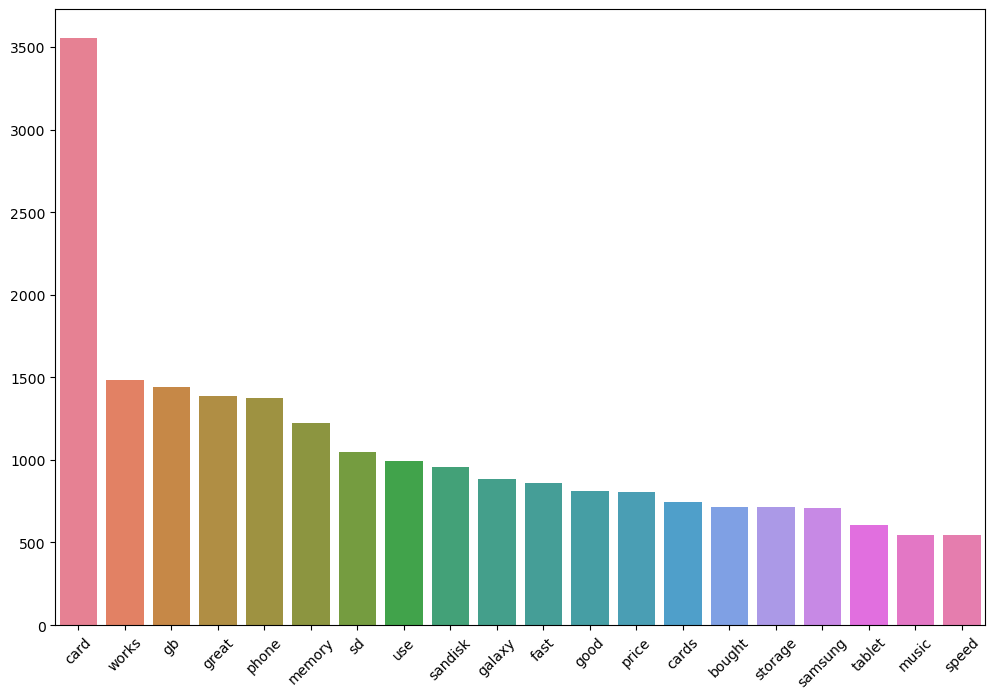

In [95]:
plt.figure(figsize=(12,8))
sns.barplot(x=pozitif_data.keys(), y=pozitif_data.values(), hue=pozitif_data.keys())
plt.xticks(rotation=45);

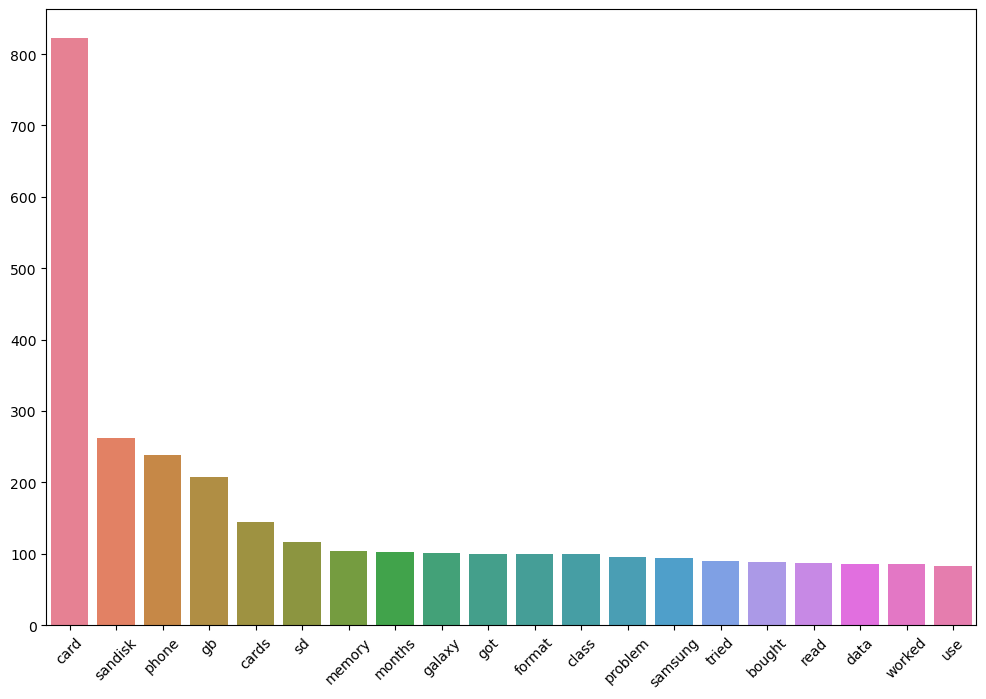

In [96]:
plt.figure(figsize=(12,8))
sns.barplot(x=negatif_data.keys(), y=negatif_data.values(), hue=negatif_data.keys())
plt.xticks(rotation=45);

In [97]:
from wordcloud import WordCloud
from wordcloud import STOPWORDS
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

In [98]:
def wc(data, color):
    plt.figure(figsize=(10, 10))
    mask=np.array(Image.open('cloud.png'))
    wc = WordCloud(background_color=color, stopwords=STOPWORDS, mask=mask)  
    wc.generate(' '.join(data))
    plt.imshow(wc)
    plt.axis('off')  
    plt.show() 

In [99]:
negatif = df[df['sentiment'] == 0]
pozitif = df[df['sentiment'] == 2]

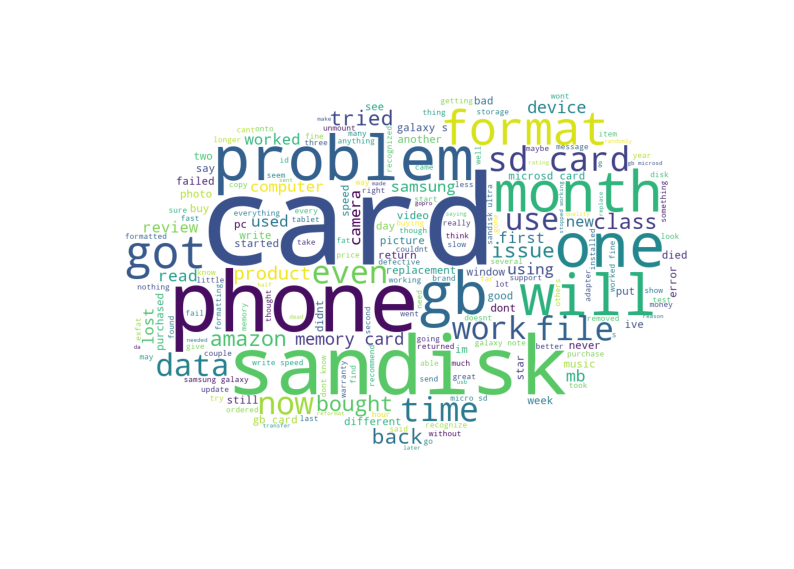

In [100]:
wc(negatif['reviewText'],'white')

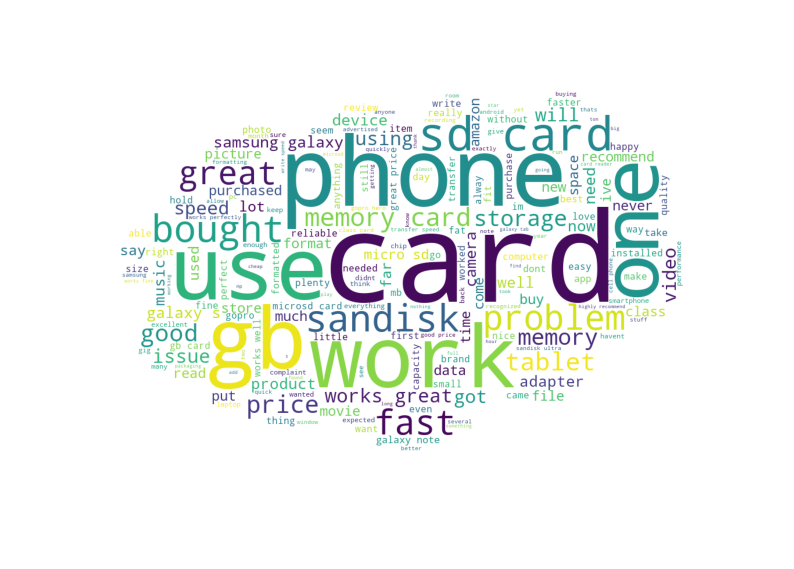

In [101]:
wc(pozitif['reviewText'],'white')

### Sentiment Analysis with machine learning

In [104]:
ybw=df[(df.overall==1.0) | (df.overall==3.0) | (df.overall==5.0) ]

In [105]:
ybw.reset_index(drop=True, inplace=True)

In [107]:
x=ybw[['reviewText']]
y=ybw[['sentiment']]

In [108]:
x.head()

,reviewText
0,purchased this for my device it worked as advertised you can never have too much phone memory since i download a lot of stuff this was a no brainer for me
1,this think has worked out greathad a diff bran gb card and if went south after monthsthis one has held up pretty well since i had my s now on my note update ive had this for a few months and have had zero issues since it was transferred from my s to my note and into a note this card is reliable and solidcheers
2,bought it with retail packaging arrived legit in a orange envelope english version not asian like the picture shows arrived quickly bought a and both retail packaging for my htc one sv and lg optimus both cards in working order probably best price youll get for a nice sd card
3,its mini storage it doesnt do anything else and its not supposed to i purchased it to add additional storage to my microsoft surface pro tablet which only come in and gb it does what its supposed to and sandisk has a long standing reputation that speaks for itself
4,i have it in my phone and it never skips a beat file transfers are speedy and have not had any corruption issues or memory fade issues as i would expect from the sandisk brand great card to own why entrust your precious files to a slightly cheaper piece of crap if you lose everything can you forgive yourself for not spending the extra couple bucks on a trusted product that goes through good qa


In [112]:
y.head()

,sentiment
0,2
1,2
2,2
3,2
4,2


In [113]:
yenix=vect.fit_transform(x['reviewText'])

In [114]:
x_train, x_test, y_train, y_test=train_test_split(yenix,y, random_state=42, test_size=.20)

In [115]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.naive_bayes import BernoulliNB

from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.metrics import f1_score, confusion_matrix, classification_report
from sklearn.model_selection import train_test_split

b = BernoulliNB()
l = LogisticRegression()
d = DecisionTreeClassifier()
r = RandomForestClassifier()
gb= GradientBoostingClassifier()
kn= KNeighborsClassifier()
ab= AdaBoostClassifier()
mn= MultinomialNB()

def algo_test(x, y):
    modeller=[ b, l, d, r, gb, kn, ab, mn]
    isimler=["BernoulliNB", "LogisticRegression", "DecisionTreeClassifier", 
             "RandomForestClassifier", "GradientBoostingClassifier", "KNeighborsClassifier",
             "AdaBoostClassifier", "MultinomialNB"]

    x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=.20, random_state = 42)
    
    accuracy = []
    precision = []
    recall = []
    f1 = []
    mdl=[]

    print("Veriler hazır modeller deneniyor")
    for model in modeller:
        print(model, " modeli eğitiliyor!..")
        model=model.fit(x_train,y_train)
        tahmin=model.predict(x_test)
        mdl.append(model)
        accuracy.append(accuracy_score(y_test, tahmin))
        precision.append(precision_score(y_test, tahmin, average="micro"))
        recall.append(recall_score(y_test, tahmin, average="micro"))
        f1.append(f1_score(y_test, tahmin, average="micro"))
        print(confusion_matrix(y_test, tahmin))

    print("Eğitim tamamlandı.")
    
    metrics=pd.DataFrame(columns=["Accuracy", "Precision", "Recall", "F1", "Model"], index=isimler)
    metrics["Accuracy"] = accuracy
    metrics["Precision"] = precision  
    metrics["Recall"] = recall
    metrics["F1"] = f1
    metrics["Model"]=mdl

    metrics.sort_values("F1", ascending=False, inplace=True)

    print("En başarılı model: ", metrics.iloc[0].name)
    model=metrics.iloc[0,-1]
    tahmin=model.predict(np.array(x_test) if model==kn else x_test)
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, tahmin))
    print("classification Report:")
    print(classification_report(y_test, tahmin))
    print("Diğer Modeller:")
    
    return metrics.drop("Model", axis=1)

In [116]:
algo_test(yenix,y)

Veriler hazır modeller deneniyor
BernoulliNB()  modeli eğitiliyor!..
[[ 16   0  28]
 [  7   0  25]
 [ 15   1 765]]
LogisticRegression()  modeli eğitiliyor!..
[[ 29   7   8]
 [  7   3  22]
 [  7   4 770]]
DecisionTreeClassifier()  modeli eğitiliyor!..
[[ 21   5  18]
 [  8   1  23]
 [ 32  12 737]]
RandomForestClassifier()  modeli eğitiliyor!..
[[ 10   0  34]
 [  1   0  31]
 [  3   0 778]]
GradientBoostingClassifier()  modeli eğitiliyor!..
[[ 15   3  26]
 [  5   0  27]
 [  8   2 771]]
KNeighborsClassifier()  modeli eğitiliyor!..
[[  4   1  39]
 [  0   0  32]
 [  2   2 777]]
AdaBoostClassifier()  modeli eğitiliyor!..
[[  3   0  41]
 [  1   0  31]
 [  0   0 781]]
MultinomialNB()  modeli eğitiliyor!..
[[ 27   1  16]
 [  5   0  27]
 [ 13   2 766]]
Eğitim tamamlandı.
En başarılı model:  LogisticRegression
Confusion Matrix:
[[ 29   7   8]
 [  7   3  22]
 [  7   4 770]]
classification Report:
              precision    recall  f1-score   support

           0       0.67      0.66      0.67      

,Accuracy,Precision,Recall,F1
LogisticRegression,0.935823,0.935823,0.935823,0.935823
MultinomialNB,0.925321,0.925321,0.925321,0.925321
RandomForestClassifier,0.919487,0.919487,0.919487,0.919487
GradientBoostingClassifier,0.917153,0.917153,0.917153,0.917153
AdaBoostClassifier,0.914819,0.914819,0.914819,0.914819
BernoulliNB,0.911319,0.911319,0.911319,0.911319
KNeighborsClassifier,0.911319,0.911319,0.911319,0.911319
DecisionTreeClassifier,0.885648,0.885648,0.885648,0.885648


Makine öğrenmesi algoritmaları ile elde edilen sonuçlara göre en yüksek performans RandomForestClassifier modeli tarafından sağlanmış ve %95 doğruluk accuracy, precision, recall ve F1 skorlarına ulaşılmıştır. MultinomialNB ve diğer modeller de benzer şekilde yaklaşık %91-92 bandında performans göstermiştir. 

Derin öğrenme modeli ise %92 doğruluk oranı ve 0.27 loss değeri ile tüm makine öğrenmesi modellerine kıyasla daha yüksek bir performans sergilemiştir.

According to the results obtained with machine learning algorithms, the highest performance was provided by the RandomForestClassifier model, achieving 95% accuracy, precision, recall, and F1 scores. MultinomialNB and other models similarly showed performance in the approximately 91-92% range.

The deep learning model, however, exhibited higher performance compared to all other machine learning models, with a 92% accuracy rate and a loss value of 0.27.

In [117]:
import joblib
from sklearn.feature_extraction.text import TfidfVectorizer

r=RandomForestClassifier()
best_model=r.fit(x_train, y_train)

# Modelinizi ve vectorizer'ı kaydedin
joblib.dump(best_model, 'sentiment_model.joblib')
joblib.dump(vect, 'vectorizer.joblib')

['vectorizer.joblib']